=== RÉSULTATS DE L'ÉVALUATION DU CLUSTERING ===
SSE: 71.5461
Cohesion_Cosine: 107.2331
SSB: 1851.4214
TSS: 1922.9675
Silhouette: 0.7908
TSS_Check: 1.0000
Graph_Cohesion: 602.9377
Graph_Separation: 0.0000
Proto_Cohesion: 91.6270
Proto_Separation_Cluster: 17.2118
Proto_Separation_Global: 8.6712
CPCC: 0.8479
purity: 1.0000
entropy: 0.0000
precision: 1.0000
recall: 1.0000
f1_score: 1.0000
correlation: 1.0000


KeyError: 'Purity'

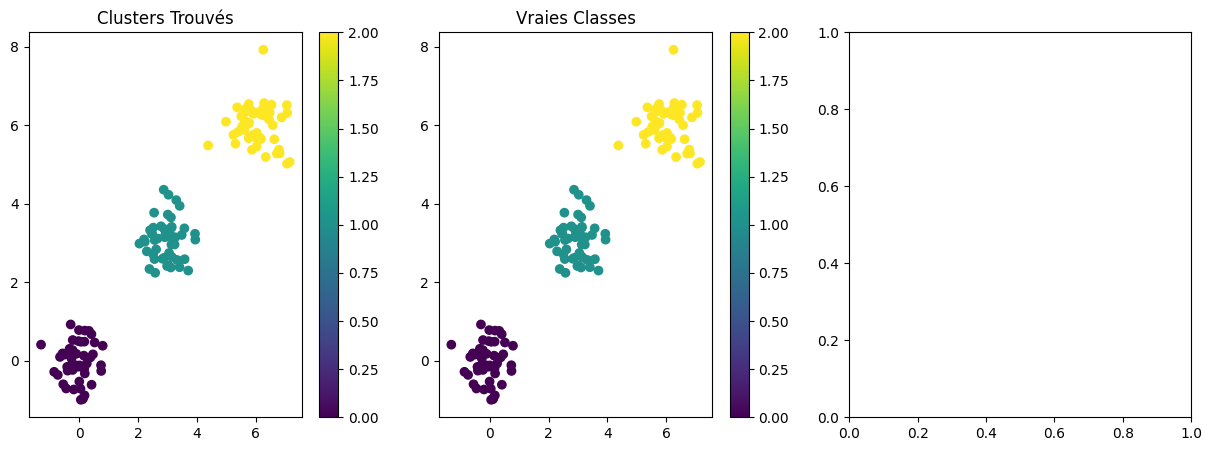

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist, pdist, squareform
from scipy.cluster.hierarchy import linkage, cophenet
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd

class ClusterEvaluator:
    def __init__(self, data, labels, true_labels=None):
        """
        data: array 2D des points (n_samples, n_features)
        labels: labels des clusters trouvés
        true_labels: vrais labels (pour évaluation supervisée)
        """
        self.data = np.array(data)
        self.labels = np.array(labels)
        self.true_labels = np.array(true_labels) if true_labels is not None else None
        self.n_clusters = len(np.unique(labels))
        self.clusters = [self.data[self.labels == i] for i in range(self.n_clusters)]
        
    def calculate_centroids(self):
        """Calcule les centroïdes de chaque cluster"""
        centroids = []
        for cluster in self.clusters:
            if len(cluster) > 0:
                centroids.append(np.mean(cluster, axis=0))
            else:
                centroids.append(np.zeros(self.data.shape[1]))
        return np.array(centroids)
    
    def sse(self):
        """Sum of Squared Error - Cohésion"""
        centroids = self.calculate_centroids()
        sse_total = 0
        for i, cluster in enumerate(self.clusters):
            if len(cluster) > 0:
                distances = cdist(cluster, [centroids[i]], metric='euclidean')
                sse_total += np.sum(distances**2)
        return sse_total
    
    def cohesion_cosine(self):
        """Cohésion basée sur la similarité cosinus"""
        centroids = self.calculate_centroids()
        total_cohesion = 0
        
        for i, cluster in enumerate(self.clusters):
            if len(cluster) > 0:
                centroid = centroids[i]
                # Normalisation pour calcul cosinus
                cluster_norm = cluster / np.linalg.norm(cluster, axis=1, keepdims=True)
                centroid_norm = centroid / np.linalg.norm(centroid)
                cosine_similarities = np.dot(cluster_norm, centroid_norm)
                total_cohesion += np.sum(cosine_similarities)
        
        return total_cohesion
    
    def ssb(self):
        """Between Group Sum of Squares - Séparation"""
        centroids = self.calculate_centroids()
        global_centroid = np.mean(self.data, axis=0)
        ssb_total = 0
        
        for i, cluster in enumerate(self.clusters):
            if len(cluster) > 0:
                distance = np.linalg.norm(centroids[i] - global_centroid)
                ssb_total += len(cluster) * (distance**2)
        
        return ssb_total
    
    def tss(self):
        """Total Sum of Squares"""
        global_centroid = np.mean(self.data, axis=0)
        distances = cdist(self.data, [global_centroid], metric='euclidean')
        return np.sum(distances**2)
    
    def silhouette_coefficient(self):
        """Coefficient de Silhouette"""
        if len(self.data) > 1000:  # Échantillonnage pour grandes datasets
            indices = np.random.choice(len(self.data), 1000, replace=False)
            data_sample = self.data[indices]
            labels_sample = self.labels[indices]
        else:
            data_sample = self.data
            labels_sample = self.labels
            
        n_samples = len(data_sample)
        silhouette_scores = np.zeros(n_samples)
        
        for i in range(n_samples):
            point = data_sample[i]
            cluster_label = labels_sample[i]
            
            # Distance moyenne aux points du même cluster (a_i)
            same_cluster_mask = labels_sample == cluster_label
            same_cluster_points = data_sample[same_cluster_mask]
            
            if len(same_cluster_points) > 1:
                distances_same = cdist([point], same_cluster_points, metric='euclidean')[0]
                a_i = np.sum(distances_same) / (len(same_cluster_points) - 1)
            else:
                a_i = 0
            
            # Distance moyenne aux points des autres clusters (b_i)
            other_cluster_dists = []
            for other_cluster in range(self.n_clusters):
                if other_cluster != cluster_label:
                    other_cluster_mask = labels_sample == other_cluster
                    if np.sum(other_cluster_mask) > 0:
                        other_cluster_points = data_sample[other_cluster_mask]
                        distances_other = cdist([point], other_cluster_points, metric='euclidean')[0]
                        avg_dist = np.mean(distances_other)
                        other_cluster_dists.append(avg_dist)
            
            if other_cluster_dists:
                b_i = min(other_cluster_dists)
                silhouette_scores[i] = (b_i - a_i) / max(a_i, b_i)
            else:
                silhouette_scores[i] = 0
        
        return np.mean(silhouette_scores)
    
    def graph_based_cohesion_separation(self, k=5):
        """Cohésion et séparation basées sur les k-plus proches voisins"""
        from sklearn.neighbors import NearestNeighbors
        
        nbrs = NearestNeighbors(n_neighbors=k+1).fit(self.data)
        distances, indices = nbrs.kneighbors(self.data)
        
        # Matrice d'adjacence basée sur k-plus proches voisins
        adjacency = np.zeros((len(self.data), len(self.data)))
        for i in range(len(self.data)):
            for j in indices[i][1:]:  # Exclure le point lui-même
                adjacency[i, j] = 1 / (1 + distances[i, list(indices[i]).index(j)])
        
        cohesion = 0
        separation = 0
        
        for i in range(self.n_clusters):
            cluster_mask = self.labels == i
            # Cohésion: liens intra-cluster
            intra_links = adjacency[cluster_mask][:, cluster_mask]
            cohesion += np.sum(intra_links)
            
            # Séparation: liens inter-cluster
            for j in range(i+1, self.n_clusters):
                other_cluster_mask = self.labels == j
                inter_links = adjacency[cluster_mask][:, other_cluster_mask]
                separation += np.sum(inter_links)
        
        return cohesion, separation
    
    def prototype_based_cohesion_separation(self):
        """Cohésion et séparation basées sur les prototypes"""
        centroids = self.calculate_centroids()
        global_centroid = np.mean(self.data, axis=0)
        
        cohesion = 0
        for i, cluster in enumerate(self.clusters):
            if len(cluster) > 0:
                distances = cdist(cluster, [centroids[i]], metric='euclidean')
                cohesion += np.sum(distances)
        
        # Séparation entre clusters
        cluster_separation = 0
        for i in range(self.n_clusters):
            for j in range(i+1, self.n_clusters):
                distance = np.linalg.norm(centroids[i] - centroids[j])
                cluster_separation += distance
        
        # Séparation avec centroïde global
        global_separation = 0
        for i in range(self.n_clusters):
            distance = np.linalg.norm(centroids[i] - global_centroid)
            global_separation += distance
        
        return cohesion, cluster_separation, global_separation
    
    def hierarchical_evaluation(self):
        """Évaluation du clustering hiérarchique"""
        # Matrice de dissimilarité originale
        original_distances = squareform(pdist(self.data, metric='euclidean'))
        
        # Clustering hiérarchique
        Z = linkage(self.data, method='average')
        
        # Matrice cophénétique
        coph_dist, coph_matrix = cophenet(Z, pdist(self.data))
        
        return coph_dist, coph_matrix, original_distances
    
    def supervised_measures(self):
        """Mesures supervisées de qualité"""
        if self.true_labels is None:
            return None
        
        le = LabelEncoder()
        true_encoded = le.fit_transform(self.true_labels)
        pred_encoded = le.transform(self.labels)
        
        # Pureté
        purity = self._calculate_purity(true_encoded, pred_encoded)
        
        # Entropie
        entropy = self._calculate_entropy(true_encoded, pred_encoded)
        
        # Précision, Rappel, F-mesure
        precision = precision_score(true_encoded, pred_encoded, average='weighted')
        recall = recall_score(true_encoded, pred_encoded, average='weighted')
        f1 = f1_score(true_encoded, pred_encoded, average='weighted')
        
        # Similarité entre matrices
        correlation = self._similarity_correlation(true_encoded, pred_encoded)
        
        return {
            'purity': purity,
            'entropy': entropy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'correlation': correlation
        }
    
    def _calculate_purity(self, true_labels, pred_labels):
        """Calcule la pureté des clusters"""
        contingency_matrix = np.zeros((self.n_clusters, len(np.unique(true_labels))))
        
        for true_lab, pred_lab in zip(true_labels, pred_labels):
            contingency_matrix[pred_lab, true_lab] += 1
        
        purity = 0
        for cluster in range(self.n_clusters):
            purity += np.max(contingency_matrix[cluster])
        
        return purity / len(true_labels)
    
    def _calculate_entropy(self, true_labels, pred_labels):
        """Calcule l'entropie des clusters"""
        contingency_matrix = np.zeros((self.n_clusters, len(np.unique(true_labels))))
        
        for true_lab, pred_lab in zip(true_labels, pred_labels):
            contingency_matrix[pred_lab, true_lab] += 1
        
        entropy = 0
        for cluster in range(self.n_clusters):
            cluster_size = np.sum(contingency_matrix[cluster])
            if cluster_size > 0:
                proportions = contingency_matrix[cluster] / cluster_size
                proportions = proportions[proportions > 0]  # Éviter log(0)
                cluster_entropy = -np.sum(proportions * np.log2(proportions))
                entropy += (cluster_size / len(true_labels)) * cluster_entropy
        
        return entropy
    
    def _similarity_correlation(self, true_labels, pred_labels):
        """Corrélation entre matrices de similarité idéales"""
        n = len(true_labels)
        C = np.zeros((n, n))  # Matrice cluster idéale
        L = np.zeros((n, n))  # Matrice classe idéale
        
        for i in range(n):
            for j in range(n):
                C[i, j] = 1 if pred_labels[i] == pred_labels[j] else 0
                L[i, j] = 1 if true_labels[i] == true_labels[j] else 0
        
        # Corrélation de Pearson
        correlation = np.corrcoef(C.flatten(), L.flatten())[0, 1]
        return correlation
    
    def evaluate_all(self):
        """Évalue toutes les métriques"""
        results = {}
        
        # Métriques non supervisées
        results['SSE'] = self.sse()
        results['Cohesion_Cosine'] = self.cohesion_cosine()
        results['SSB'] = self.ssb()
        results['TSS'] = self.tss()
        results['Silhouette'] = self.silhouette_coefficient()
        
        # Vérification théorème TSS = SSE + SSB
        results['TSS_Check'] = abs(results['TSS'] - (results['SSE'] + results['SSB'])) < 1e-10
        
        # Métriques basées sur les graphes
        cohesion_graph, separation_graph = self.graph_based_cohesion_separation()
        results['Graph_Cohesion'] = cohesion_graph
        results['Graph_Separation'] = separation_graph
        
        # Métriques basées sur les prototypes
        cohesion_proto, separation_cluster, separation_global = self.prototype_based_cohesion_separation()
        results['Proto_Cohesion'] = cohesion_proto
        results['Proto_Separation_Cluster'] = separation_cluster
        results['Proto_Separation_Global'] = separation_global
        
        # Évaluation hiérarchique
        coph_corr, coph_matrix, orig_matrix = self.hierarchical_evaluation()
        results['CPCC'] = coph_corr
        
        # Métriques supervisées
        if self.true_labels is not None:
            supervised_results = self.supervised_measures()
            results.update(supervised_results)
        
        return results

# Exemple d'utilisation
if __name__ == "__main__":
    # Données d'exemple
    np.random.seed(42)
    
    # Génération de données clusterisées
    cluster1 = np.random.normal(0, 0.5, (50, 2))
    cluster2 = np.random.normal(3, 0.5, (50, 2))
    cluster3 = np.random.normal(6, 0.5, (50, 2))
    
    data = np.vstack([cluster1, cluster2, cluster3])
    true_labels = np.array([0]*50 + [1]*50 + [2]*50)
    
    # Labels de clustering (parfait dans cet exemple)
    cluster_labels = np.array([0]*50 + [1]*50 + [2]*50)
    
    # Évaluation
    evaluator = ClusterEvaluator(data, cluster_labels, true_labels)
    results = evaluator.evaluate_all()
    
    # Affichage des résultats
    print("=== RÉSULTATS DE L'ÉVALUATION DU CLUSTERING ===")
    for metric, value in results.items():
        print(f"{metric}: {value:.4f}")
    
    # Visualisation
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.scatter(data[:, 0], data[:, 1], c=cluster_labels, cmap='viridis')
    plt.title('Clusters Trouvés')
    plt.colorbar()
    
    plt.subplot(1, 3, 2)
    plt.scatter(data[:, 0], data[:, 1], c=true_labels, cmap='viridis')
    plt.title('Vraies Classes')
    plt.colorbar()
    
    plt.subplot(1, 3, 3)
    metrics = ['SSE', 'Silhouette', 'Purity' if 'purity' in results else 'CPCC']
    values = [results[m] for m in metrics]
    plt.bar(metrics, values)
    plt.title('Métriques de Qualité')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

RÉSULTATS DE L'ÉVALUATION DU CLUSTERING

--- MÉTRIQUES NON SUPERVISÉES ---
SSE.................: 71.5461
Cohesion_Cosine.....: 107.2331
SSB.................: 1851.4214
TSS.................: 1922.9675
Silhouette..........: 0.7908
Calinski_Harabasz...: 1901.9844
Davies_Bouldin......: 0.2869
CPCC................: 0.8479

--- MÉTRIQUES SUPERVISÉES ---
Purity..............: 1.0000
Adjusted_Rand_Index.: 1.0000
Normalized_Mutual_Info: 1.0000
Homogeneity.........: 1.0000
Completeness........: 1.0000
V_Measure...........: 1.0000


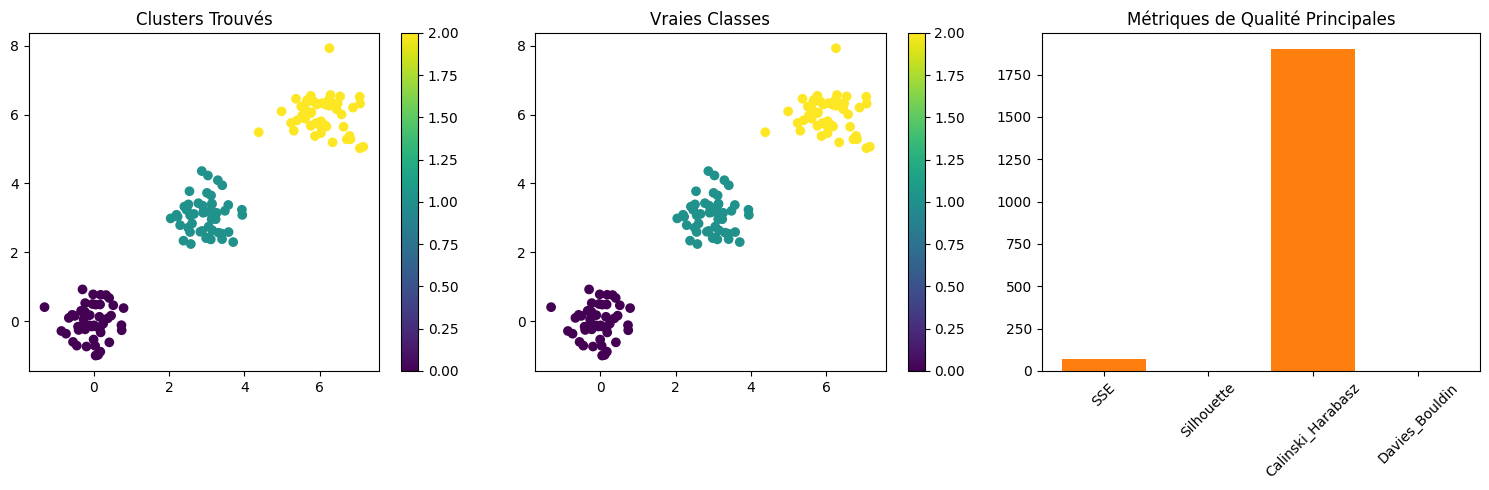

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist, pdist, squareform
from scipy.cluster.hierarchy import linkage, cophenet
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, homogeneity_completeness_v_measure
from sklearn.preprocessing import LabelEncoder
import pandas as pd

class ClusterEvaluator:
    def __init__(self, data, labels, true_labels=None):
        """
        data: array 2D des points (n_samples, n_features)
        labels: labels des clusters trouvés
        true_labels: vrais labels (pour évaluation supervisée)
        """
        self.data = np.array(data)
        self.labels = np.array(labels)
        self.true_labels = np.array(true_labels) if true_labels is not None else None
        self.n_clusters = len(np.unique(labels))
        self.clusters = [self.data[self.labels == i] for i in range(self.n_clusters)]
        
    def calculate_centroids(self):
        """Calcule les centroïdes de chaque cluster"""
        centroids = []
        for cluster in self.clusters:
            if len(cluster) > 0:
                centroids.append(np.mean(cluster, axis=0))
            else:
                centroids.append(np.zeros(self.data.shape[1]))
        return np.array(centroids)
    
    def sse(self):
        """Sum of Squared Error - Cohésion"""
        centroids = self.calculate_centroids()
        sse_total = 0
        for i, cluster in enumerate(self.clusters):
            if len(cluster) > 0:
                distances = cdist(cluster, [centroids[i]], metric='euclidean')
                sse_total += np.sum(distances**2)
        return sse_total
    
    def cohesion_cosine(self):
        """Cohésion basée sur la similarité cosinus"""
        centroids = self.calculate_centroids()
        total_cohesion = 0
        
        for i, cluster in enumerate(self.clusters):
            if len(cluster) > 0:
                centroid = centroids[i]
                # Normalisation pour calcul cosinus
                cluster_norm = cluster / np.linalg.norm(cluster, axis=1, keepdims=True)
                centroid_norm = centroid / np.linalg.norm(centroid)
                cosine_similarities = np.dot(cluster_norm, centroid_norm)
                total_cohesion += np.sum(cosine_similarities)
        
        return total_cohesion
    
    def ssb(self):
        """Between Group Sum of Squares - Séparation"""
        centroids = self.calculate_centroids()
        global_centroid = np.mean(self.data, axis=0)
        ssb_total = 0
        
        for i, cluster in enumerate(self.clusters):
            if len(cluster) > 0:
                distance = np.linalg.norm(centroids[i] - global_centroid)
                ssb_total += len(cluster) * (distance**2)
        
        return ssb_total
    
    def tss(self):
        """Total Sum of Squares"""
        global_centroid = np.mean(self.data, axis=0)
        distances = cdist(self.data, [global_centroid], metric='euclidean')
        return np.sum(distances**2)
    
    def silhouette_coefficient(self):
        """Coefficient de Silhouette utilisant scikit-learn"""
        try:
            return silhouette_score(self.data, self.labels)
        except:
            return 0.0
    
    def calinski_harabasz(self):
        """Score Calinski-Harabasz utilisant scikit-learn"""
        try:
            return calinski_harabasz_score(self.data, self.labels)
        except:
            return 0.0
    
    def davies_bouldin(self):
        """Score Davies-Bouldin utilisant scikit-learn"""
        try:
            return davies_bouldin_score(self.data, self.labels)
        except:
            return float('inf')
    
    def graph_based_cohesion_separation(self, k=5):
        """Cohésion et séparation basées sur les k-plus proches voisins"""
        from sklearn.neighbors import NearestNeighbors
        
        try:
            nbrs = NearestNeighbors(n_neighbors=min(k+1, len(self.data))).fit(self.data)
            distances, indices = nbrs.kneighbors(self.data)
            
            # Matrice d'adjacence basée sur k-plus proches voisins
            adjacency = np.zeros((len(self.data), len(self.data)))
            for i in range(len(self.data)):
                for j in indices[i][1:]:  # Exclure le point lui-même
                    adjacency[i, j] = 1 / (1 + distances[i, list(indices[i]).index(j)])
            
            cohesion = 0
            separation = 0
            
            for i in range(self.n_clusters):
                cluster_mask = self.labels == i
                # Cohésion: liens intra-cluster
                intra_links = adjacency[cluster_mask][:, cluster_mask]
                cohesion += np.sum(intra_links)
                
                # Séparation: liens inter-cluster
                for j in range(i+1, self.n_clusters):
                    other_cluster_mask = self.labels == j
                    inter_links = adjacency[cluster_mask][:, other_cluster_mask]
                    separation += np.sum(inter_links)
            
            return cohesion, separation
        except:
            return 0.0, 0.0
    
    def prototype_based_cohesion_separation(self):
        """Cohésion et séparation basées sur les prototypes"""
        try:
            centroids = self.calculate_centroids()
            global_centroid = np.mean(self.data, axis=0)
            
            cohesion = 0
            for i, cluster in enumerate(self.clusters):
                if len(cluster) > 0:
                    distances = cdist(cluster, [centroids[i]], metric='euclidean')
                    cohesion += np.sum(distances)
            
            # Séparation entre clusters
            cluster_separation = 0
            for i in range(self.n_clusters):
                for j in range(i+1, self.n_clusters):
                    distance = np.linalg.norm(centroids[i] - centroids[j])
                    cluster_separation += distance
            
            # Séparation avec centroïde global
            global_separation = 0
            for i in range(self.n_clusters):
                distance = np.linalg.norm(centroids[i] - global_centroid)
                global_separation += distance
            
            return cohesion, cluster_separation, global_separation
        except:
            return 0.0, 0.0, 0.0
    
    def hierarchical_evaluation(self):
        """Évaluation du clustering hiérarchique"""
        try:
            # Matrice de dissimilarité originale
            original_distances = squareform(pdist(self.data, metric='euclidean'))
            
            # Clustering hiérarchique
            Z = linkage(self.data, method='average')
            
            # Matrice cophénétique
            coph_dist, coph_matrix = cophenet(Z, pdist(self.data))
            
            return coph_dist
        except:
            return 0.0
    
    def supervised_measures(self):
        """Mesures supervisées de qualité utilisant scikit-learn"""
        if self.true_labels is None:
            return {}
        
        try:
            results = {}
            
            # Métriques de similarité
            results['Adjusted_Rand_Index'] = adjusted_rand_score(self.true_labels, self.labels)
            results['Normalized_Mutual_Info'] = normalized_mutual_info_score(self.true_labels, self.labels)
            
            # Homogénéité, complétude et V-mesure
            homogeneity, completeness, v_measure = homogeneity_completeness_v_measure(self.true_labels, self.labels)
            results['Homogeneity'] = homogeneity
            results['Completeness'] = completeness
            results['V_Measure'] = v_measure
            
            # Pureté personnalisée
            results['Purity'] = self._calculate_purity()
            
            return results
        except:
            return {}
    
    def _calculate_purity(self):
        """Calcule la pureté des clusters"""
        try:
            contingency_matrix = np.zeros((self.n_clusters, len(np.unique(self.true_labels))))
            
            for true_lab, pred_lab in zip(self.true_labels, self.labels):
                contingency_matrix[pred_lab, true_lab] += 1
            
            purity = 0
            for cluster in range(self.n_clusters):
                purity += np.max(contingency_matrix[cluster])
            
            return purity / len(self.true_labels)
        except:
            return 0.0
    
    def evaluate_all(self):
        """Évalue toutes les métriques avec gestion robuste des erreurs"""
        results = {}
        
        try:
            # Métriques non supervisées de base
            results['SSE'] = self.sse()
            results['Cohesion_Cosine'] = self.cohesion_cosine()
            results['SSB'] = self.ssb()
            results['TSS'] = self.tss()
            
            # Vérification théorème TSS = SSE + SSB
            results['TSS_Check'] = abs(results['TSS'] - (results['SSE'] + results['SSB'])) < 1e-10
            
            # Métriques non supervisées avancées (scikit-learn)
            results['Silhouette'] = self.silhouette_coefficient()
            results['Calinski_Harabasz'] = self.calinski_harabasz()
            results['Davies_Bouldin'] = self.davies_bouldin()
            
            # Métriques basées sur les graphes
            cohesion_graph, separation_graph = self.graph_based_cohesion_separation()
            results['Graph_Cohesion'] = cohesion_graph
            results['Graph_Separation'] = separation_graph
            
            # Métriques basées sur les prototypes
            cohesion_proto, separation_cluster, separation_global = self.prototype_based_cohesion_separation()
            results['Proto_Cohesion'] = cohesion_proto
            results['Proto_Separation_Cluster'] = separation_cluster
            results['Proto_Separation_Global'] = separation_global
            
            # Évaluation hiérarchique
            results['CPCC'] = self.hierarchical_evaluation()
            
        except Exception as e:
            print(f"Erreur dans les métriques non supervisées: {e}")
        
        # Métriques supervisées
        try:
            if self.true_labels is not None:
                supervised_results = self.supervised_measures()
                results.update(supervised_results)
        except Exception as e:
            print(f"Erreur dans les métriques supervisées: {e}")
        
        return results

    def print_results(self, results):
        """Affiche les résultats de manière organisée"""
        print("=" * 60)
        print("RÉSULTATS DE L'ÉVALUATION DU CLUSTERING")
        print("=" * 60)
        
        # Métriques non supervisées
        print("\n--- MÉTRIQUES NON SUPERVISÉES ---")
        unsup_metrics = ['SSE', 'Cohesion_Cosine', 'SSB', 'TSS', 'Silhouette', 
                        'Calinski_Harabasz', 'Davies_Bouldin', 'CPCC']
        for metric in unsup_metrics:
            if metric in results:
                print(f"{metric:.<20}: {results[metric]:.4f}")
        
        # Métriques supervisées
        if self.true_labels is not None:
            print("\n--- MÉTRIQUES SUPERVISÉES ---")
            sup_metrics = ['Purity', 'Adjusted_Rand_Index', 'Normalized_Mutual_Info', 
                          'Homogeneity', 'Completeness', 'V_Measure']
            for metric in sup_metrics:
                if metric in results:
                    print(f"{metric:.<20}: {results[metric]:.4f}")

# Exemple d'utilisation
if __name__ == "__main__":
    # Données d'exemple
    np.random.seed(42)
    
    # Génération de données clusterisées
    cluster1 = np.random.normal(0, 0.5, (50, 2))
    cluster2 = np.random.normal(3, 0.5, (50, 2))
    cluster3 = np.random.normal(6, 0.5, (50, 2))
    
    data = np.vstack([cluster1, cluster2, cluster3])
    true_labels = np.array([0]*50 + [1]*50 + [2]*50)
    
    # Labels de clustering (parfait dans cet exemple)
    cluster_labels = np.array([0]*50 + [1]*50 + [2]*50)
    
    # Évaluation
    evaluator = ClusterEvaluator(data, cluster_labels, true_labels)
    results = evaluator.evaluate_all()
    
    # Affichage des résultats
    evaluator.print_results(results)
    
    # Visualisation
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.scatter(data[:, 0], data[:, 1], c=cluster_labels, cmap='viridis')
    plt.title('Clusters Trouvés')
    plt.colorbar()
    
    plt.subplot(1, 3, 2)
    if true_labels is not None:
        plt.scatter(data[:, 0], data[:, 1], c=true_labels, cmap='viridis')
        plt.title('Vraies Classes')
        plt.colorbar()
    
    plt.subplot(1, 3, 3)
    # Sélection des métriques principales qui existent
    main_metrics = ['SSE', 'Silhouette', 'Calinski_Harabasz']
    available_metrics = [m for m in main_metrics if m in results]
    values = [results[m] for m in available_metrics]
    
    plt.bar(available_metrics, values)
    plt.title('Métriques de Qualité Principales')
    plt.xticks(rotation=45)
    
    # Ajustement de l'échelle pour Davies-Bouldin si présent
    if 'Davies_Bouldin' in results and results['Davies_Bouldin'] < 100:
        available_metrics.append('Davies_Bouldin')
        values.append(results['Davies_Bouldin'])
        plt.bar(available_metrics, values)
    
    plt.tight_layout()
    plt.show()